# 1. Carga de datos

In [6]:
from pathlib import Path

# __file__ no funciona en notebooks, así que usamos Path.cwd()
# Subimos dos niveles: notebooks/ -> src/ -> repo/
repo_root = Path.cwd().parent.parent

dataset_path = repo_root / "data" / "chemical_process_timeseries.csv"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df = pd.read_csv(filepath_or_buffer=dataset_path,sep=",")

In [8]:
print(df.shape)
print(df.dtypes)
print(df.head())

(777600, 21)
timestamp                   str
operating_regime            str
reactor_id                  str
ambient_temp_effect     float64
reactor_temp            float64
reactor_pressure        float64
feed_flow_rate          float64
coolant_flow_rate       float64
agitator_speed_rpm      float64
reaction_rate           float64
conversion_rate         float64
selectivity             float64
yield_pct               float64
vibration_rms           float64
motor_current           float64
power_consumption_kw    float64
temp_setpoint           float64
pressure_setpoint       float64
fault_type                int64
efficiency_loss_pct     float64
time_to_fault_min       float64
dtype: object
             timestamp operating_regime reactor_id  ambient_temp_effect  \
0  2024-01-01 00:00:00                A       A_R1             0.000000   
1  2024-01-01 00:01:00                A       A_R1             0.000485   
2  2024-01-01 00:02:00                A       A_R1             0.000970   
3

In [9]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Rango temporal: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Duración total: {df['timestamp'].max() - df['timestamp'].min()}")
print(f"Frecuencia de muestreo estimada: {df['timestamp'].diff().mode()[0]}")

Rango temporal: 2024-01-01 00:00:00 → 2024-03-30 23:59:00
Duración total: 89 days 23:59:00
Frecuencia de muestreo estimada: 0 days 00:00:00


# 2. EDA

## 2.1 Identificación de valores nulos

In [10]:
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)

null_df = pd.DataFrame({"nulos": nulls, "porcentaje": nulls_pct})
null_df = null_df[null_df["nulos"] > 0].sort_values("porcentaje", ascending=False)
print(null_df)

                       nulos  porcentaje
time_to_fault_min     751313       96.62
selectivity            47209        6.07
reactor_pressure       47143        6.06
reactor_temp           46965        6.04
efficiency_loss_pct    46919        6.03
reaction_rate          46830        6.02
pressure_setpoint      46818        6.02
agitator_speed_rpm     46775        6.02
feed_flow_rate         46760        6.01
coolant_flow_rate      46645        6.00
ambient_temp_effect    46561        5.99
motor_current          46617        5.99
yield_pct              46524        5.98
temp_setpoint          46522        5.98
power_consumption_kw   46494        5.98
conversion_rate        46416        5.97
vibration_rms          46459        5.97


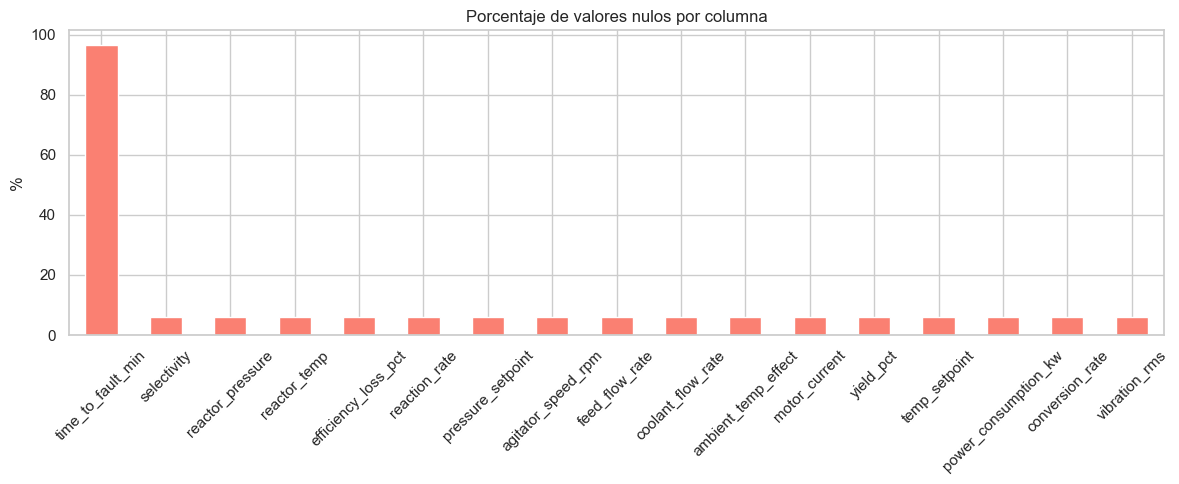

In [11]:
null_df["porcentaje"].plot(kind="bar", color="salmon")
plt.title("Porcentaje de valores nulos por columna")
plt.ylabel("%")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# Verificar si los nulos están en las mismas filas
sensor_cols = [col for col in df.columns if col not in 
               ["timestamp", "operating_regime", "reactor_id", "fault_type", "time_to_fault_min"]]

null_rows = df[sensor_cols].isnull().any(axis=1)
print(f"Filas con al menos un nulo en sensores: {null_rows.sum()}")
print(f"Filas con TODOS los sensores a NaN: {df[sensor_cols].isnull().all(axis=1).sum()}")

Filas con al menos un nulo en sensores: 489136
Filas con TODOS los sensores a NaN: 0


Los nulos están dispersos en filas distintas, no son caídas totales del sistema. Esto significa que hay fallos puntuales de sensores individuales, y eliminar filas no es viable porque perderíamos demasiada información (~63% de las filas tiene algún nulo).
La estrategia correcta aquí es imputación, y dado que es una serie temporal con diferentes reactores y regímenes, aplicaremos interpolación temporal por grupos.

## 2.2 Imputación de valores nulos

In [13]:
# Ordenar por reactor y tiempo antes de interpolar
df = df.sort_values(["reactor_id", "operating_regime", "timestamp"]).reset_index(drop=True)

In [14]:
# Interpolación temporal dentro de cada grupo reactor + régimen
df[sensor_cols] = df.groupby(["reactor_id", "operating_regime"])[sensor_cols] \
                    .transform(lambda x: x.interpolate(method="linear", limit=10))

In [15]:

for col in sensor_cols:
    df[col] = df.groupby(["reactor_id", "operating_regime"])[col] \
                .transform(lambda x: x.fillna(x.median()))

remaining = df[sensor_cols].isnull().sum().sum()
print(f"Nulos restantes en sensores: {remaining}")
print(df.isnull().sum())

Nulos restantes en sensores: 0
timestamp                    0
operating_regime             0
reactor_id                   0
ambient_temp_effect          0
reactor_temp                 0
reactor_pressure             0
feed_flow_rate               0
coolant_flow_rate            0
agitator_speed_rpm           0
reaction_rate                0
conversion_rate              0
selectivity                  0
yield_pct                    0
vibration_rms                0
motor_current                0
power_consumption_kw         0
temp_setpoint                0
pressure_setpoint            0
fault_type                   0
efficiency_loss_pct          0
time_to_fault_min       751313
dtype: int64


In [16]:
df["time_to_fault_min"] = df["time_to_fault_min"].fillna(-1)

# Verificación
print(df["time_to_fault_min"].isnull().sum())  # Debe dar 0
print(df["time_to_fault_min"].value_counts().head())

0
time_to_fault_min
-1.0      751313
 187.0        35
 180.0        35
 178.0        35
 169.0        35
Name: count, dtype: int64


In [17]:
print(f"Total filas: {len(df)}")
print(f"Filas sin fallo (time_to_fault = -1): {(df['time_to_fault_min'] == -1).sum()}")
print(f"Filas con fallo registrado: {(df['time_to_fault_min'] != -1).sum()}")
print(f"Nulos totales en el dataset: {df.isnull().sum().sum()}")

Total filas: 777600
Filas sin fallo (time_to_fault = -1): 751313
Filas con fallo registrado: 26287
Nulos totales en el dataset: 0


## 2.3 Outliers

Los boxplots pueden ser útiles para identificar valores extremos.

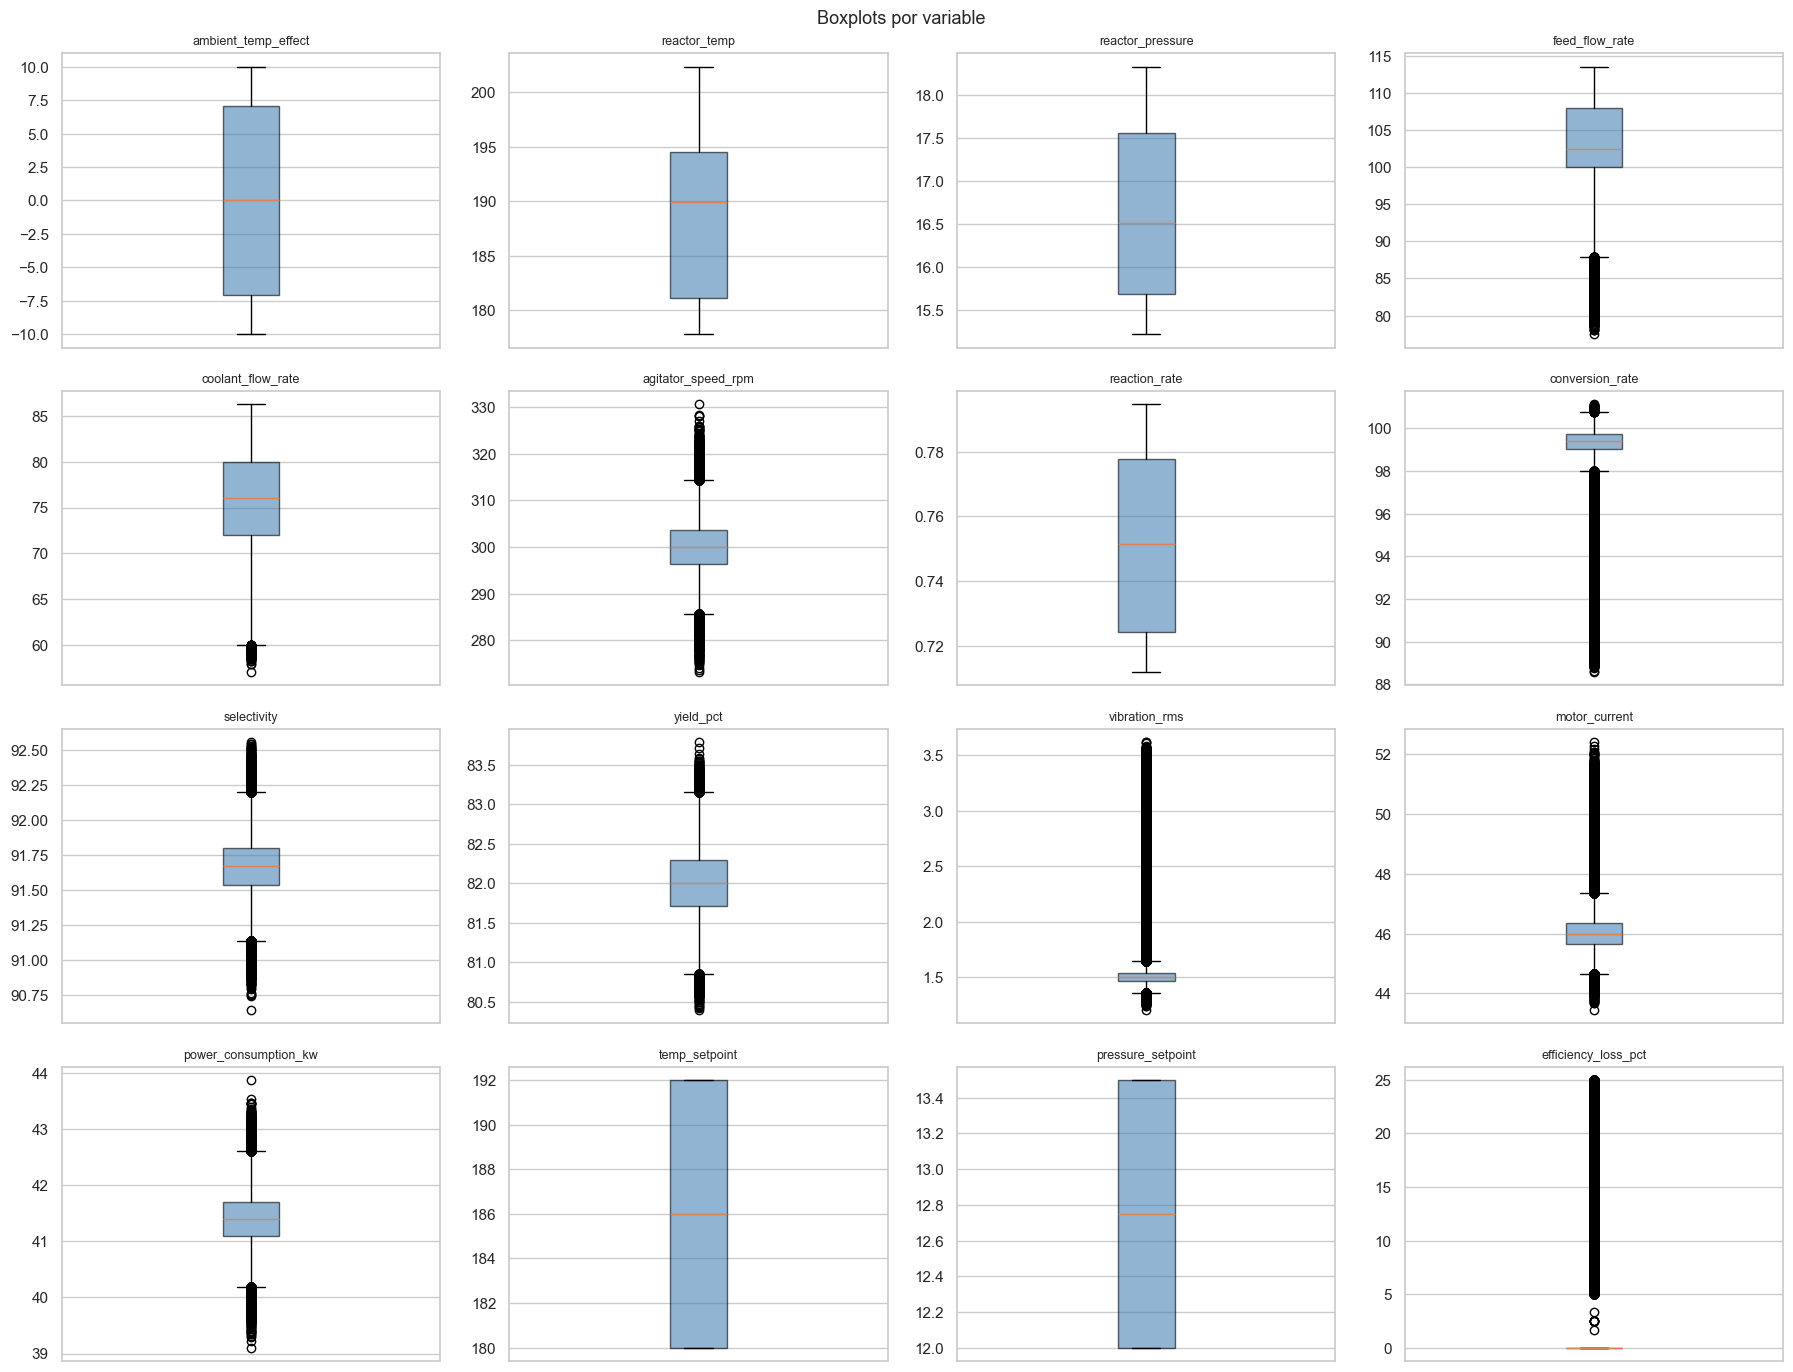

In [18]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.6))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xticks([])

# Ocultar subplots sobrantes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots por variable", fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
def detect_outliers_iqr(df, cols):
    results = []
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        results.append({
            "columna": col,
            "lower_bound": round(lower, 3),
            "upper_bound": round(upper, 3),
            "n_outliers": n_outliers,
            "pct_outliers": round(n_outliers / len(df) * 100, 2)
        })
    return pd.DataFrame(results).sort_values("pct_outliers", ascending=False)

outlier_df = detect_outliers_iqr(df, sensor_cols)
print(outlier_df)

                 columna  lower_bound  upper_bound  n_outliers  pct_outliers
15   efficiency_loss_pct        0.000        0.000       27908          3.59
10         vibration_rms        1.355        1.646       13919          1.79
11         motor_current       44.643       47.372       10976          1.41
5     agitator_speed_rpm      285.561      314.428        7253          0.93
7        conversion_rate       98.008      100.773        6105          0.79
8            selectivity       91.136       92.199        5962          0.77
12  power_consumption_kw       40.185       42.617        5994          0.77
3         feed_flow_rate       87.950      120.019        1593          0.20
9              yield_pct       80.855       83.150        1450          0.19
4      coolant_flow_rate       60.008       91.938         108          0.01
1           reactor_temp      161.049      214.547           0          0.00
2       reactor_pressure       12.863       20.373           0          0.00

In [20]:
# Si los outliers se concentran en fault_type != 0, son información valiosa, no ruido
for col in outlier_df[outlier_df["pct_outliers"] > 1]["columna"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)
    
    fault_dist = df.loc[mask, "fault_type"].value_counts(normalize=True).round(3)
    print(f"\n{col} — distribución de fault_type en outliers:")
    print(fault_dist)


efficiency_loss_pct — distribución de fault_type en outliers:
fault_type
1    0.328
4    0.267
2    0.245
3    0.160
0    0.000
Name: proportion, dtype: float64

vibration_rms — distribución de fault_type en outliers:
fault_type
4    0.495
0    0.489
1    0.007
2    0.005
3    0.005
Name: proportion, dtype: float64

motor_current — distribución de fault_type en outliers:
fault_type
4    0.494
0    0.491
1    0.006
2    0.005
3    0.004
Name: proportion, dtype: float64


In [21]:

for col in ["vibration_rms", "motor_current"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)
    
    print(f"\n{col} — outliers en fault_type=0 por reactor:")
    print(df.loc[mask & (df["fault_type"] == 0), "reactor_id"].value_counts())
    print(f"\n{col} — outliers en fault_type=0 por operating_regime:")
    print(df.loc[mask & (df["fault_type"] == 0), "operating_regime"].value_counts())


vibration_rms — outliers en fault_type=0 por reactor:
reactor_id
B_R2    1879
B_R3    1829
B_R1    1799
A_R1     450
A_R3     436
A_R2     411
Name: count, dtype: int64

vibration_rms — outliers en fault_type=0 por operating_regime:
operating_regime
B    5507
A    1297
Name: count, dtype: int64

motor_current — outliers en fault_type=0 por reactor:
reactor_id
B_R2    951
B_R1    936
B_R3    905
A_R3    878
A_R1    868
A_R2    855
Name: count, dtype: int64

motor_current — outliers en fault_type=0 por operating_regime:
operating_regime
B    2792
A    2601
Name: count, dtype: int64


Los outliers están distribuidos por todos los reactores y ambos regímenes, no hay concentración en ninguno en particular. Eso descarta que sean errores de un sensor específico o un reactor defectuoso.
La conclusión general es que en este dataset no hay outliers que deban tratarse. Los valores extremos tienen explicación física o están directamente relacionados con los fallos. Eliminarlos empeoraría el modelo.

## 2.4 Distribución de variables

In [22]:
for col in ["operating_regime", "reactor_id"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- operating_regime ---
operating_regime
A    388800
B    388800
Name: count, dtype: int64

--- reactor_id ---
reactor_id
A_R1    129600
A_R2    129600
A_R3    129600
B_R1    129600
B_R2    129600
B_R3    129600
Name: count, dtype: int64


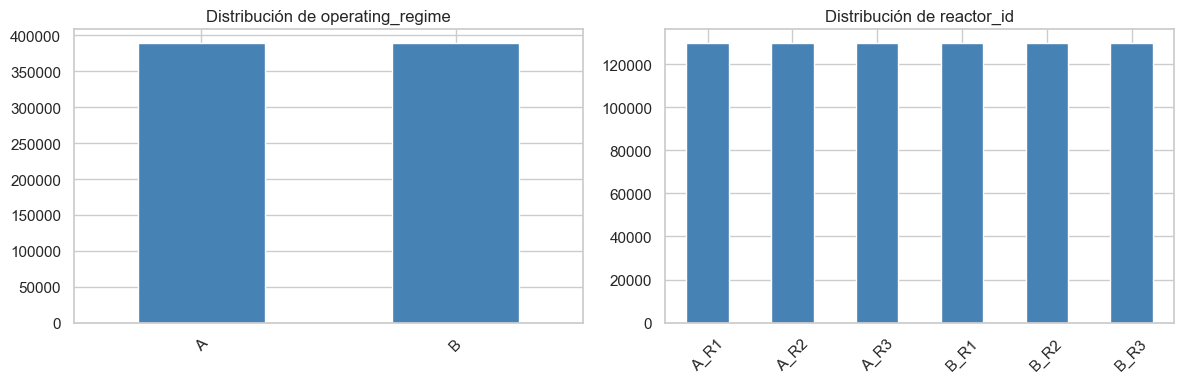

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["operating_regime", "reactor_id"]):
    df[col].value_counts().plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

                         count     mean      std      min      25%      50%  \
ambient_temp_effect   777600.0   -0.000    7.071  -10.000   -7.071   -0.000   
reactor_temp          777600.0  187.966    6.764  177.794  181.111  189.931   
reactor_pressure      777600.0   16.622    0.959   15.214   15.680   16.516   
feed_flow_rate        777600.0  103.914    4.295   77.477   99.976  102.506   
coolant_flow_rate     777600.0   75.943    4.432   57.025   71.982   75.993   
agitator_speed_rpm    777600.0  299.994    5.440  273.136  296.386  299.984   
reaction_rate         777600.0    0.752    0.027    0.712    0.724    0.752   
conversion_rate       777600.0   99.352    0.703   88.575   99.045   99.390   
selectivity           777600.0   91.668    0.198   90.645   91.535   91.668   
yield_pct             777600.0   82.003    0.400   80.399   81.716   82.002   
vibration_rms         777600.0    1.510    0.125    1.204    1.464    1.501   
motor_current         777600.0   46.024    0.577   4

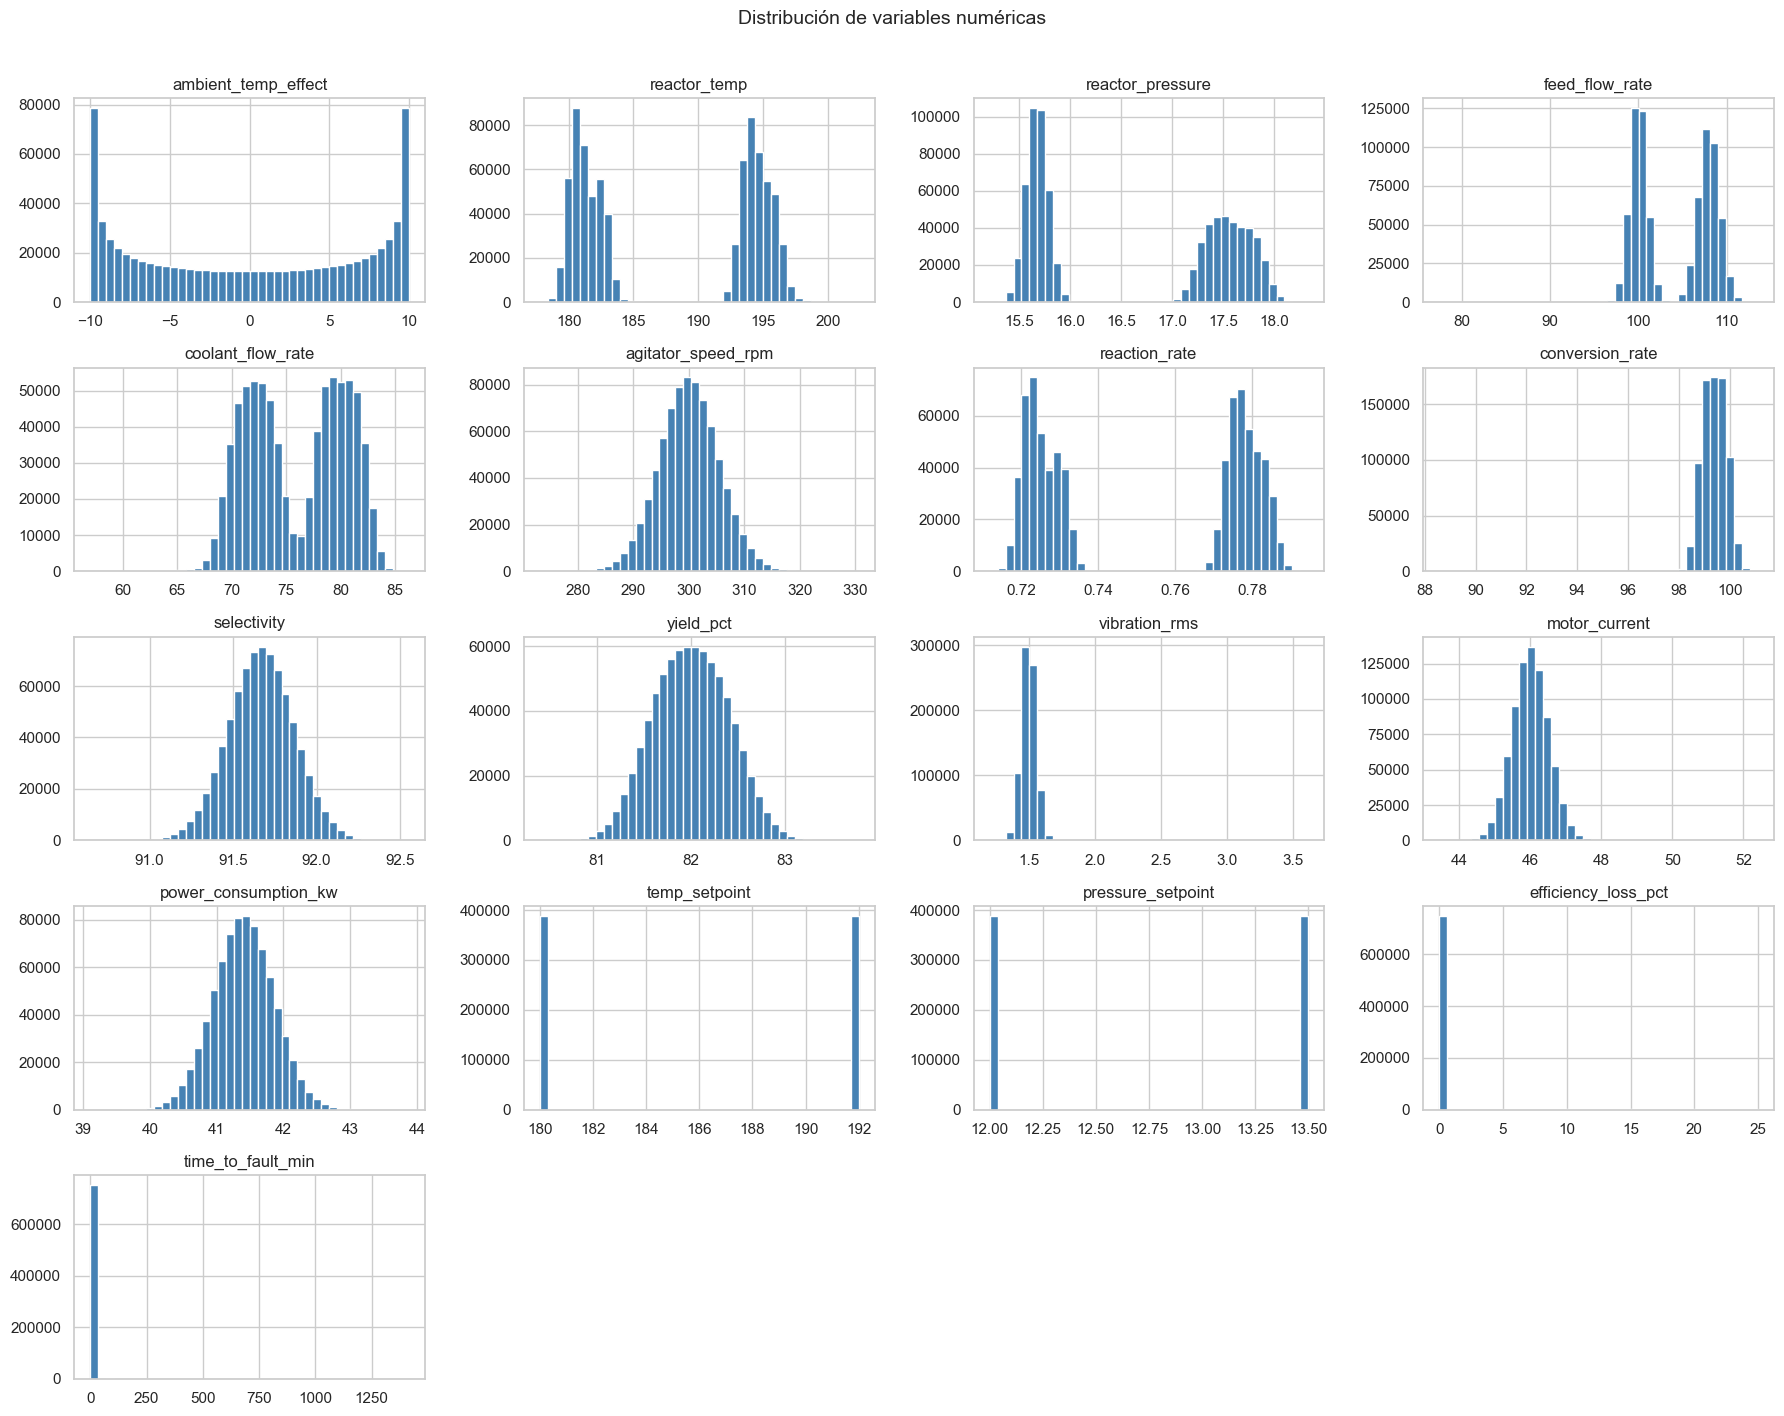

In [24]:
num_cols = df.select_dtypes(include="float64").columns.tolist()
print(df[num_cols].describe().T.round(3))
df[num_cols].hist(bins=40, figsize=(18, 14), color="steelblue", edgecolor="white")
plt.suptitle("Distribución de variables numéricas", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
print(df["fault_type"].value_counts())
print(f"\nClases: {sorted(df['fault_type'].unique())}")

fault_type
0    749699
1      9143
4      7442
2      6842
3      4474
Name: count, dtype: int64

Clases: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


### Variable objetivo fault_type

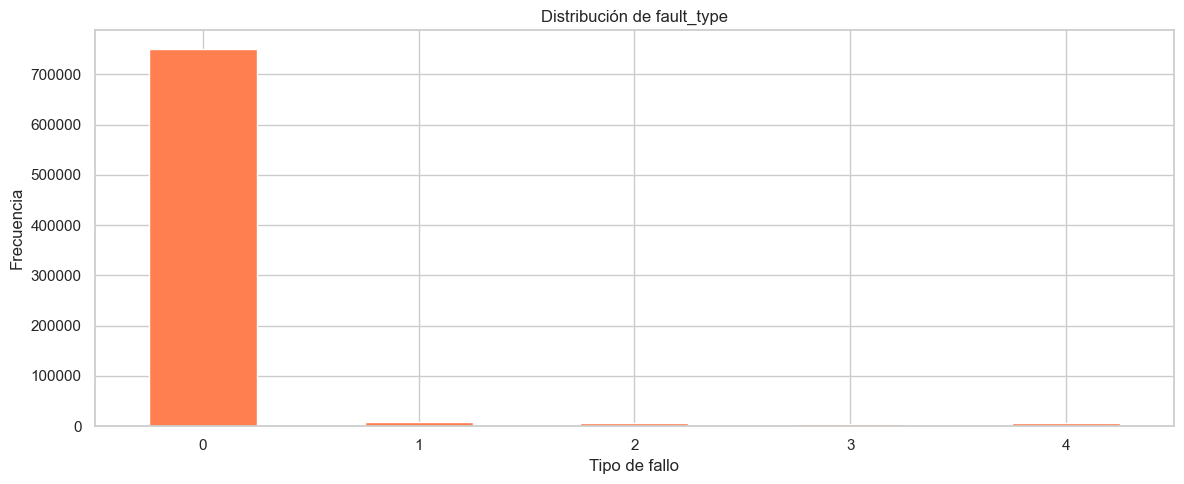

In [26]:
df["fault_type"].value_counts().sort_index().plot(kind="bar", color="coral")
plt.title("Distribución de fault_type")
plt.xlabel("Tipo de fallo")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

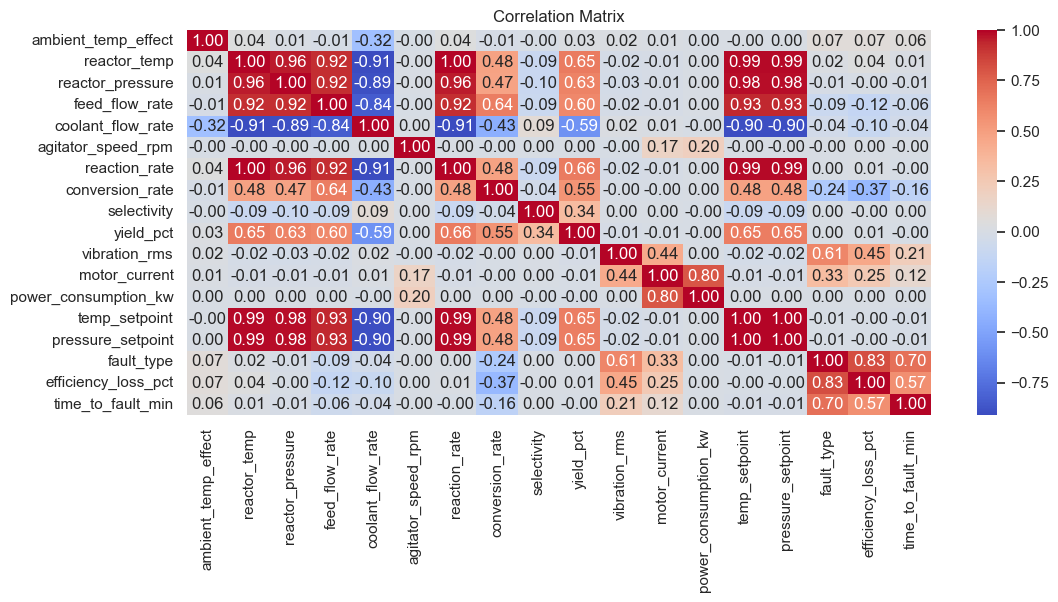

In [27]:
corr = df.corr(numeric_only=True)
plt.figure()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [28]:
corr = df.corr(numeric_only=True)

corr_target = corr['time_to_fault_min'].drop('time_to_fault_min')
corr_target = corr_target.sort_values(ascending=False)

print(corr_target)

fault_type              0.696775
efficiency_loss_pct     0.567465
vibration_rms           0.213374
motor_current           0.116101
ambient_temp_effect     0.057139
reactor_temp            0.011505
selectivity             0.002417
power_consumption_kw    0.000009
agitator_speed_rpm     -0.000183
yield_pct              -0.001408
reaction_rate          -0.003894
temp_setpoint          -0.012826
pressure_setpoint      -0.012826
reactor_pressure       -0.014478
coolant_flow_rate      -0.044985
feed_flow_rate         -0.064479
conversion_rate        -0.163300
Name: time_to_fault_min, dtype: float64


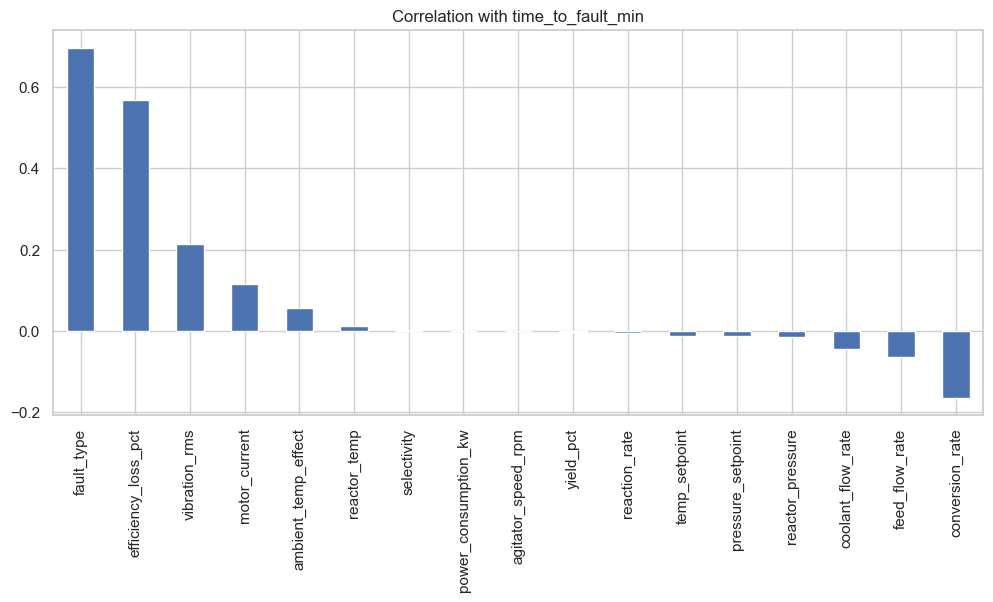

In [29]:
corr_target.plot(kind='bar')
plt.title("Correlation with time_to_fault_min")
plt.show()

In [30]:
from sklearn.feature_selection import mutual_info_classif

X = df.drop(columns=['fault_type'])
X = X.select_dtypes(include='number')  # solo numéricas

y = df['fault_type']

mi = mutual_info_classif(X, y)

mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

print(mi_series)

efficiency_loss_pct     0.152368
time_to_fault_min       0.139695
pressure_setpoint       0.100443
temp_setpoint           0.079163
ambient_temp_effect     0.065502
vibration_rms           0.047527
conversion_rate         0.042986
reactor_temp            0.038205
motor_current           0.035636
feed_flow_rate          0.034745
coolant_flow_rate       0.026818
reaction_rate           0.008083
reactor_pressure        0.003585
yield_pct               0.000903
agitator_speed_rpm      0.000121
selectivity             0.000055
power_consumption_kw    0.000000
dtype: float64


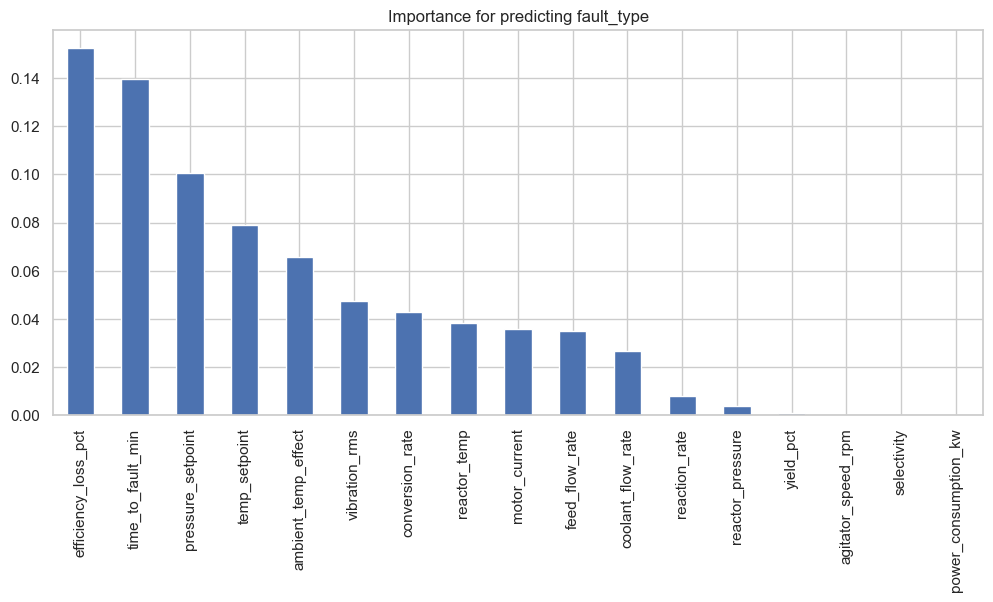

In [31]:
mi_series.plot(kind='bar')
plt.title("Importance for predicting fault_type")
plt.show()

# ML

In [35]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [41]:
df_class = df.dropna(subset=["fault_type"])

X_class = df_class.drop(columns=["fault_type", "time_to_fault_min"])
y_class = df_class["fault_type"]

In [42]:
categorical_features = X_class.select_dtypes(include=["object"]).columns
numeric_features = X_class.select_dtypes(include=["int64", "float64"]).columns

print("Categorical:", list(categorical_features))
print("Numeric:", list(numeric_features))

Categorical: ['operating_regime', 'reactor_id']
Numeric: ['ambient_temp_effect', 'reactor_temp', 'reactor_pressure', 'feed_flow_rate', 'coolant_flow_rate', 'agitator_speed_rpm', 'reaction_rate', 'conversion_rate', 'selectivity', 'yield_pct', 'vibration_rms', 'motor_current', 'power_consumption_kw', 'temp_setpoint', 'pressure_setpoint', 'efficiency_loss_pct']


C:\Users\Usuario\AppData\Local\Temp\ipykernel_22488\4235675239.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_class.select_dtypes(include=["object"]).columns


In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [57]:
clf_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            class_weight="balanced",
            random_state=32,
            n_jobs=-1
        ))
    ]
)

In [58]:
df_class = df.dropna(subset=["fault_type"])

X_class = df_class.drop(columns=["fault_type", "time_to_fault_min"])
y_class = df_class["fault_type"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=32,
    stratify=y_class
)

In [59]:
clf_pipeline.fit(X_train_c, y_train_c)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [60]:
y_pred_c = clf_pipeline.predict(X_test_c)

print("Accuracy:", accuracy_score(y_test_c, y_pred_c))

print("\nClassification Report:\n")
print(classification_report(y_test_c, y_pred_c))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_c, y_pred_c))

Accuracy: 0.9992091049382716

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    149940
           1       0.98      0.98      0.98      1829
           2       1.00      0.97      0.98      1368
           3       0.92      0.99      0.95       895
           4       0.99      0.98      0.99      1488

    accuracy                           1.00    155520
   macro avg       0.98      0.98      0.98    155520
weighted avg       1.00      1.00      1.00    155520


Confusion Matrix:

[[149940      0      0      0      0]
 [     0   1790      1     38      0]
 [     0      4   1321     35      8]
 [     0      6      0    889      0]
 [     1     20      5      5   1457]]


In [51]:
df_reg = df.dropna(subset=["time_to_fault_min"])

X_reg = df_reg.drop(columns=["fault_type", "time_to_fault_min"])
y_reg = df_reg["time_to_fault_min"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=32
)

In [52]:
reg_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            n_jobs=-1,
            random_state=32
        ))
    ]
)

In [53]:
reg_pipeline.fit(X_train_r, y_train_r)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [54]:
y_pred_r = reg_pipeline.predict(X_test_r)

mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2 = r2_score(y_test_r, y_pred_r)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2.6965394208967264
RMSE: 28.337444017011197
R2: 0.9299682277313143


In [67]:
import joblib

joblib.dump(clf_pipeline, "fault_classification_model.pkl")

['fault_classification_model.pkl']

In [68]:
joblib.dump(reg_pipeline, "time_to_fault_model.pkl")

['time_to_fault_model.pkl']